In [1]:
# Binary Classification on CT Patches
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

warnings.filterwarnings("ignore")

from pre_process_data import PreProcessData
from datasets import CTPatchDataset

In [21]:
@dataclass
class Config:
    project_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
    exp1_path = project_root / "data" / "Experiment 1 - Blind"
    exp2_path = project_root / "data" / "Experiment 2 - Open"

    exp1_labels_csv = project_root / "data" / "labels_exp1.csv"
    exp2_labels_csv = project_root / "data" / "labels_exp2.csv"

    export_root = project_root / "processed_dataset"
    combined_csv = export_root / "combined_labels.csv"
    train_csv = export_root / "train_labels.csv"
    test_csv = export_root / "test_labels.csv"

    # Model weights output directory
    weights_dir = project_root / "model_weights"

    volume_key = "volume"
    patch_size = 32          # 32×32 focuses tightly on the nodule region
    jitter_px = 2            # small jitter to avoid exact duplicates
    augment_train = True
    augment_eval = False

    # Annotation expansion
    expand_depth = 3         # centre ± 3 slices = 7 slices per normal annotation
    tb_slices_per_uuid = 15  # random slices sampled from each TB volume
    tb_coords_per_slice = 3  # random (x,y) positions per slice for TB volumes

    batch_size = 32
    epochs = 100              # allow deep, thorough training
    lr = 5e-4                 # slightly higher start to explore the loss landscape
    weight_decay = 1e-4
    test_size = 0.2

    # Early stopping — lax patience so training runs far before giving up
    early_stop_patience = 15  # epochs without improvement before halting
    min_delta = 1e-4          # minimum change to qualify as improvement

    # CosineAnnealingWarmRestarts: restarts at epochs 10, 30, 70
    # giving aggressive LR oscillations that escape shallow local minima
    cosine_T0     = 10        # length of first restart cycle
    cosine_T_mult = 2         # cycle length doubles after each restart
    cosine_eta_min = 1e-6     # floor LR

    seed = 6767

    # Prefer MPS (Apple Silicon) → CUDA → CPU
    device = (
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )

CFG = Config()

print(f"Project root:  {CFG.project_root}")
print(f"Device:        {CFG.device}")
print(f"Patch size:    {CFG.patch_size}×{CFG.patch_size}")
print(f"Expand depth:  ±{CFG.expand_depth} slices per annotation")
print(f"Epochs:        {CFG.epochs}  (early-stop patience={CFG.early_stop_patience})")
print(f"LR schedule:   CosineAnnealingWarmRestarts  T0={CFG.cosine_T0}  T_mult={CFG.cosine_T_mult}")
print(f"Weights dir:   {CFG.weights_dir}")


Project root:  /Users/ningkaiyang/Desktop/CS 172B Project
Device:        mps
Patch size:    32×32
Expand depth:  ±3 slices per annotation
Epochs:        100  (early-stop patience=15)
LR schedule:   CosineAnnealingWarmRestarts  T0=10  T_mult=2
Weights dir:   /Users/ningkaiyang/Desktop/CS 172B Project/model_weights


In [3]:
# Reproducibility
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
torch.cuda.manual_seed_all(CFG.seed)

# Use deterministic behavior where possible
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Preprocessing
This cell converts DICOM folders into per-patient `volume.npz` files only when needed, then merges labels from both experiments into one table.

In [4]:
def preprocess_and_merge_labels(cfg: Config) -> pd.DataFrame:
    cfg.export_root.mkdir(parents=True, exist_ok=True)

    exp1_df = pd.read_csv(cfg.exp1_labels_csv).copy()
    exp2_df = pd.read_csv(cfg.exp2_labels_csv).copy()

    exp1_df["source"] = "exp1"
    exp2_df["source"] = "exp2"

    all_df = pd.concat([exp1_df, exp2_df], ignore_index=True)
    expected_uuids = set(all_df["uuid"].astype(str).unique())

    def _all_processed() -> bool:
        if not cfg.combined_csv.exists():
            return False
        for uuid in expected_uuids:
            if not (cfg.export_root / uuid / "volume.npz").exists():
                return False
        return True

    if _all_processed():
        print("Processed volumes and combined labels already exist. Skipping preprocessing.")
        return pd.read_csv(cfg.combined_csv)

    print("Running preprocessing for missing outputs...")
    if cfg.exp1_path.exists():
        PreProcessData(cfg.exp1_path, cfg.export_root).run()
    if cfg.exp2_path.exists():
        PreProcessData(cfg.exp2_path, cfg.export_root).run()

    combined_df = pd.concat([exp1_df, exp2_df], ignore_index=True).drop_duplicates()
    combined_df["uuid"] = combined_df["uuid"].astype(str)
    combined_df.to_csv(cfg.combined_csv, index=False)
    print(f"Saved merged labels: {cfg.combined_csv} ({len(combined_df)} rows)")
    return combined_df

combined_df = preprocess_and_merge_labels(CFG)
combined_df.head()

Processed volumes and combined labels already exist. Skipping preprocessing.


,type,uuid,slice,x,y,source
0,FB,1280,100,323,381,exp1
1,FB,1009,76,354,288,exp1
2,FB,7794,79,163,191,exp1
3,FB,7794,94,338,243,exp1
4,FB,2997,45,156,135,exp1


In [5]:
# Dataset inspection: processed volume availability and shape summary
uuid_dirs = sorted([p for p in CFG.export_root.iterdir() if p.is_dir()])
print(f"Processed subject folders: {len(uuid_dirs)}")

missing_npz = [p.name for p in uuid_dirs if not (p / "volume.npz").exists()]
print(f"Folders missing volume.npz: {len(missing_npz)}")

shape_rows: List[Dict] = []
for folder in uuid_dirs[:8]:
    vpath = folder / "volume.npz"
    if not vpath.exists():
        continue
    vol = np.load(vpath, allow_pickle=False)[CFG.volume_key]
    shape_rows.append({
        "uuid": folder.name,
        "shape": vol.shape,
        "min": float(vol.min()),
        "max": float(vol.max()),
        "mean": float(vol.mean()),
    })

shape_df = pd.DataFrame(shape_rows)
shape_df

Processed subject folders: 98
Folders missing volume.npz: 0


,uuid,shape,min,max,mean
0,1003,"(481, 512, 512)",0.0,1.0,0.330554
1,1005,"(471, 512, 512)",0.0,1.0,0.365006
2,1009,"(133, 512, 512)",0.0,1.0,0.339640
3,1045,"(280, 512, 512)",0.0,1.0,0.306051
4,1067,"(328, 512, 512)",0.0,1.0,0.277475
5,1201,"(133, 512, 512)",0.0,1.0,0.350304
6,1219,"(144, 512, 512)",0.0,1.0,0.274296
7,1251,"(330, 512, 512)",0.0,1.0,0.381144


## Annotation Expansion

Each raw CSV row covers a single annotated slice. We expand every annotation into a window of **centre ± `expand_depth` slices** (clamped to volume bounds) so that neighbouring slices that also contain the nodule contribute training signal.

**TB special case** – TB rows carry `(slice=0, x=0, y=0)`, encoding a volume-level label ("this whole volume is benign / untampered"). There is no single annotated coordinate, so instead we:
- Deduplicate TB entries to one row per unique UUID (same volume can appear multiple times).
- Randomly sample `tb_slices_per_uuid` uniformly-distributed slices across the full volume depth.
- For each sampled slice, pick `tb_coords_per_slice` random `(x,y)` positions, keeping each crop at least `patch_size // 2` pixels from the image border.

**Redundancy note** – Because consecutive rows come from overlapping slices of the same volume, they are not independent. The *subject-level* train/test split applied later prevents any volume from appearing in both sets, so there is no data leakage even though individual rows are correlated.

**Optional negatives** – Slices ≥10 away from every positive annotation could be flagged as "weak negatives". However, given that the TB expansion already provides many standard-tissue patches, this is omitted to avoid further label noise.

In [6]:
def expand_annotations(
    df: pd.DataFrame,
    cfg: Config,
    depth: int = 3,
    tb_slices_per_uuid: int = 15,
    tb_coords_per_slice: int = 3,
    seed: int = 42,
) -> pd.DataFrame:
    """Expand single-slice annotations to neighbouring slices.

    Normal rows (FB / FM / TM):
        Replicate the row for slices [z-depth, ..., z+depth], clamped to
        the actual volume depth.  Coordinates (x, y) are carried over
        unchanged; any augmentation-jitter still applied at load time avoids
        exact pixel-level duplicates.

    TB rows (slice=0, x=0, y=0):
        These are volume-level labels ("whole volume is benign").
        - One row per unique UUID is processed (duplicates within the CSV are
          deduplicated so each volume is sampled only once).
        - `tb_slices_per_uuid` slices are drawn uniformly at random from [0, Z).
        - For each slice, `tb_coords_per_slice` random (x,y) positions are
          chosen, staying at least patch_size//2 pixels from the image border.

    Assumptions
    -----------
    * All volumes exist under cfg.export_root/<uuid>/volume.npz.
    * The (x, y) convention in the CSV is consistent with the image array
      indexing used in CTPatchDataset; no axis swap is needed.
    * Consecutive expanded rows share anatomy and are therefore correlated —
      the downstream subject-level split prevents leakage between train and test.
    """
    rng = np.random.default_rng(seed)
    half = cfg.patch_size // 2

    is_tb_corner = (
        (df["type"] == "TB") &
        (df["slice"] == 0) &
        (df["x"] == 0) &
        (df["y"] == 0)
    )
    normal_df = df[~is_tb_corner].copy()
    tb_df     = df[is_tb_corner].copy()

    rows: List[dict] = []

    # ── Normal annotations: expand ±depth slices ─────────────────────────────
    vol_cache: Dict[str, int] = {}  # uuid → Z depth (int only; avoid holding full array)

    for _, row in normal_df.iterrows():
        uuid = str(row["uuid"])
        if uuid not in vol_cache:
            vpath = cfg.export_root / uuid / "volume.npz"
            if not vpath.exists():
                print(f"  WARNING: missing {vpath} — skipping")
                continue
            v = np.load(vpath, mmap_mode="r", allow_pickle=False)[cfg.volume_key]
            vol_cache[uuid] = v.shape  # (Z, H, W)

        Z, H, W = vol_cache[uuid]
        z_center = int(row["slice"])
        for dz in range(-depth, depth + 1):
            z = z_center + dz
            if not (0 <= z < Z):
                continue
            r = row.to_dict()
            r["slice"] = z
            rows.append(r)

    # ── TB / corner annotations: random patches across the full volume ────────
    seen_tb_uuids: set = set()
    for _, row in tb_df.iterrows():
        uuid = str(row["uuid"])
        if uuid in seen_tb_uuids:
            continue  # one expansion per volume (CSV may have duplicates)
        seen_tb_uuids.add(uuid)

        vpath = cfg.export_root / uuid / "volume.npz"
        if not vpath.exists():
            print(f"  WARNING: missing {vpath} (TB) — skipping")
            continue
        v = np.load(vpath, mmap_mode="r", allow_pickle=False)[cfg.volume_key]
        Z, H, W = v.shape

        chosen_z = rng.integers(0, Z, size=tb_slices_per_uuid)
        for z in chosen_z:
            for _ in range(tb_coords_per_slice):
                x = int(rng.integers(half, W - half))
                y = int(rng.integers(half, H - half))
                r = row.to_dict()
                r["slice"] = int(z)
                r["x"] = x
                r["y"] = y
                rows.append(r)

    expanded = pd.DataFrame(rows).reset_index(drop=True)
    expanded["uuid"] = expanded["uuid"].astype(str)

    print(
        f"Annotation expansion: {len(df)} raw rows → {len(expanded)} expanded rows\n"
        f"  Normal annotations (depth ±{depth}): {len(normal_df)} → "
        f"{len(expanded) - len(seen_tb_uuids) * tb_slices_per_uuid * tb_coords_per_slice} rows\n"
        f"  TB volumes re-sampled ({tb_slices_per_uuid} slices × {tb_coords_per_slice} coords): "
        f"{len(seen_tb_uuids)} unique UUIDs → "
        f"{len(seen_tb_uuids) * tb_slices_per_uuid * tb_coords_per_slice} rows"
    )

    return expanded


# Apply expansion to the merged labels
expanded_df = expand_annotations(
    combined_df,
    CFG,
    depth=CFG.expand_depth,
    tb_slices_per_uuid=CFG.tb_slices_per_uuid,
    tb_coords_per_slice=CFG.tb_coords_per_slice,
    seed=CFG.seed,
)
print("\n4-class distribution after expansion:")
print(expanded_df["type"].value_counts().sort_index())
expanded_df.head(10)


Annotation expansion: 163 raw rows → 1711 expanded rows
  Normal annotations (depth ±3): 148 → 1036 rows
  TB volumes re-sampled (15 slices × 3 coords): 15 unique UUIDs → 675 rows

4-class distribution after expansion:
type
FB    504
FM    287
TB    675
TM    245
Name: count, dtype: int64


,type,uuid,slice,x,y,source
0,FB,1280,97,323,381,exp1
1,FB,1280,98,323,381,exp1
2,FB,1280,99,323,381,exp1
3,FB,1280,100,323,381,exp1
4,FB,1280,101,323,381,exp1
5,FB,1280,102,323,381,exp1
6,FB,1280,103,323,381,exp1
7,FB,1009,73,354,288,exp1
8,FB,1009,74,354,288,exp1
9,FB,1009,75,354,288,exp1


UUID=1876  type=FB  annotated (z,x,y)=(144,414,181)
Volume shape: Z=308, H=512, W=512
Showing slices: [141, 142, 143, 144, 145, 146, 147]


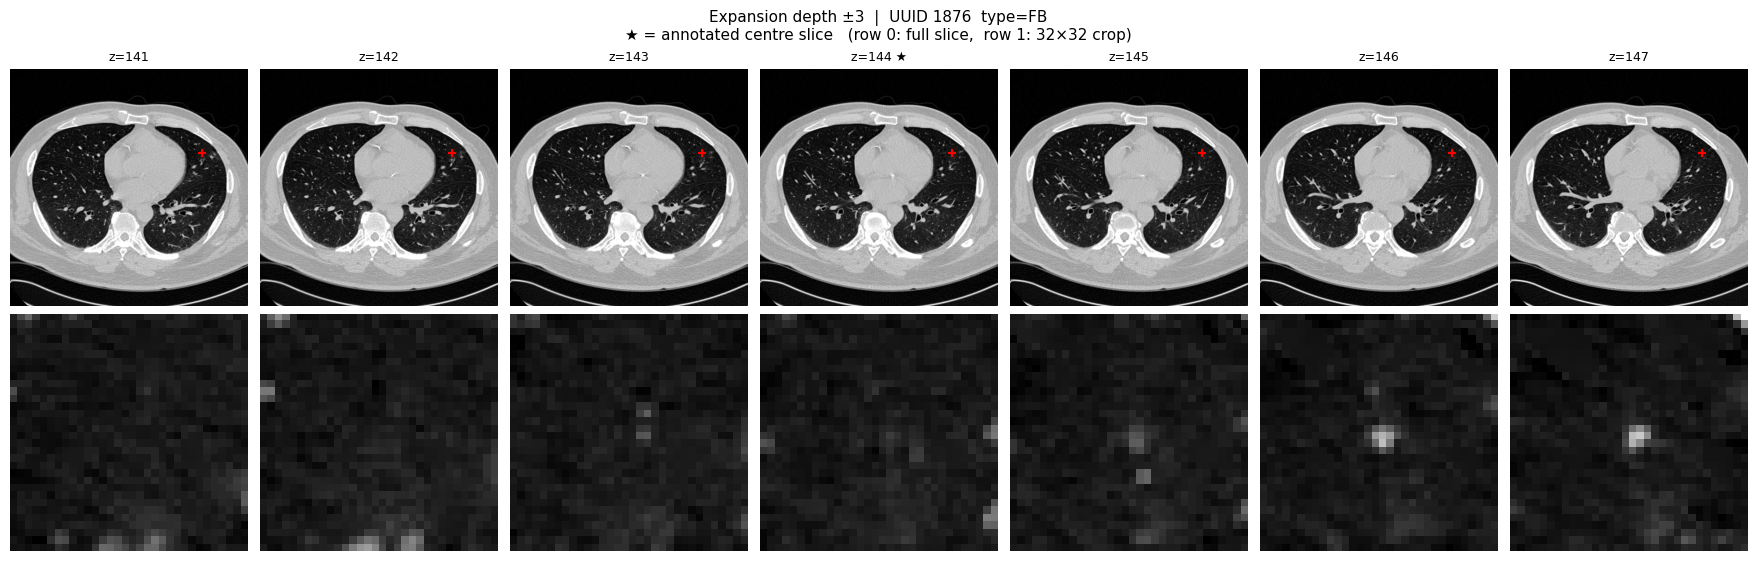

In [7]:
# ── Visualise expansion: full slices + 32×32 patches at z_center ± depth ─────
# Pick one non-TB annotation to demonstrate the expansion
vis_row = expanded_df[expanded_df["type"] != "TB"].sample(n=1, random_state=1).iloc[0]
vis_uuid   = str(vis_row["uuid"])
vis_z_orig = int(vis_row["slice"])
vis_x      = int(vis_row["x"])
vis_y      = int(vis_row["y"])
vis_type   = str(vis_row["type"])

vol_vis = np.load(CFG.export_root / vis_uuid / "volume.npz", allow_pickle=False)[CFG.volume_key]
z_indices_vis = [
    z for z in range(vis_z_orig - CFG.expand_depth, vis_z_orig + CFG.expand_depth + 1)
    if 0 <= z < vol_vis.shape[0]
]

n_z = len(z_indices_vis)
half_p = CFG.patch_size // 2

print(f"UUID={vis_uuid}  type={vis_type}  annotated (z,x,y)=({vis_z_orig},{vis_x},{vis_y})")
print(f"Volume shape: Z={vol_vis.shape[0]}, H={vol_vis.shape[1]}, W={vol_vis.shape[2]}")
print(f"Showing slices: {z_indices_vis}")

fig, axes = plt.subplots(2, n_z, figsize=(2.5 * n_z, 5.5), constrained_layout=True)
if n_z == 1:
    axes = axes.reshape(2, 1)

for col, z in enumerate(z_indices_vis):
    slc = vol_vis[z]
    H, W = slc.shape

    # Row 0: full slice with crosshair
    axes[0, col].imshow(slc, cmap="gray", vmin=0, vmax=1)
    axes[0, col].scatter([vis_x], [vis_y], c="red", s=30, marker="+")
    axes[0, col].set_title(f"z={z}" + (" ★" if z == vis_z_orig else ""), fontsize=9)
    axes[0, col].axis("off")

    # Row 1: 32×32 patch centred on (vis_x, vis_y)
    y0 = max(vis_y - half_p, 0);  y1 = min(vis_y + half_p, H)
    x0 = max(vis_x - half_p, 0);  x1 = min(vis_x + half_p, W)
    patch_vis = slc[y0:y1, x0:x1]
    axes[1, col].imshow(patch_vis, cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Full slice", fontsize=8)
axes[1, 0].set_ylabel(f"{CFG.patch_size}×{CFG.patch_size} patch", fontsize=8)
plt.suptitle(
    f"Expansion depth ±{CFG.expand_depth}  |  UUID {vis_uuid}  type={vis_type}\n"
    "★ = annotated centre slice   (row 0: full slice,  row 1: 32×32 crop)",
    fontsize=11,
)
plt.show()


## Labels and Binary Target

### Semantic clarification

The four original labels map as follows:

| Label | Meaning | Binary target |
|-------|---------|:---:|
| `FB` | False / Standard scan (Blind) | **0 — Standard** |
| `FM` | False / Standard scan (Multi-view) | **0 — Standard** |
| `TB` | True / Tampered scan (Blind) | **1 — Tampered** |
| `TM` | True / Tampered scan (Multi-view) | **1 — Tampered** |

**0 = Standard (untampered)** and **1 = Tampered**.

### Why accuracy is misleading here

The raw dataset contains roughly 70 % standard and 30 % tampered scans.  A dummy classifier that always predicts **0** will achieve ~70 % accuracy without learning anything.  We therefore also track **F1 (macro)** and **ROC-AUC** which both penalise ignoring the minority class, and we use a weighted loss and a balanced sampler to force the model to actually learn tampered-scan features.

In [8]:
# Work on the expanded dataframe produced above.
# 'source' column is already set by preprocess_and_merge_labels; preserve it.
work_df = expanded_df.copy()
work_df["uuid"] = work_df["uuid"].astype(str)

# 4-class distribution after expansion
class_counts = work_df["type"].value_counts().sort_index()
print("4-class distribution (expanded):")
print(class_counts)

# Binary mapping:
#   0 = Standard (untampered)  → FB, FM
#   1 = Tampered               → TB, TM
binary_map = {"FB": 0, "FM": 0, "TB": 1, "TM": 1}
work_df["target"] = work_df["type"].map(binary_map)

if work_df["target"].isna().any():
    bad = work_df.loc[work_df["target"].isna(), "type"].unique()
    raise ValueError(f"Found unknown labels in 'type': {bad}")

print("\nBinary distribution (expanded):")
print(
    work_df["target"].value_counts().sort_index()
    .rename({0: "0=Standard", 1: "1=Tampered"})
)

# pos_weight = #negative / #positive  (used in BCEWithLogitsLoss)
n_neg = int((work_df["target"] == 0).sum())
n_pos = int((work_df["target"] == 1).sum())
pos_weight_val = n_neg / n_pos
print(f"\nn_standard={n_neg}  n_tampered={n_pos}  pos_weight={pos_weight_val:.3f}")

work_df.head()


4-class distribution (expanded):
type
FB    504
FM    287
TB    675
TM    245
Name: count, dtype: int64

Binary distribution (expanded):
target
0=Standard    791
1=Tampered    920
Name: count, dtype: int64

n_standard=791  n_tampered=920  pos_weight=0.860


,type,uuid,slice,x,y,source,target
0,FB,1280,97,323,381,exp1,0
1,FB,1280,98,323,381,exp1,0
2,FB,1280,99,323,381,exp1,0
3,FB,1280,100,323,381,exp1,0
4,FB,1280,101,323,381,exp1,0


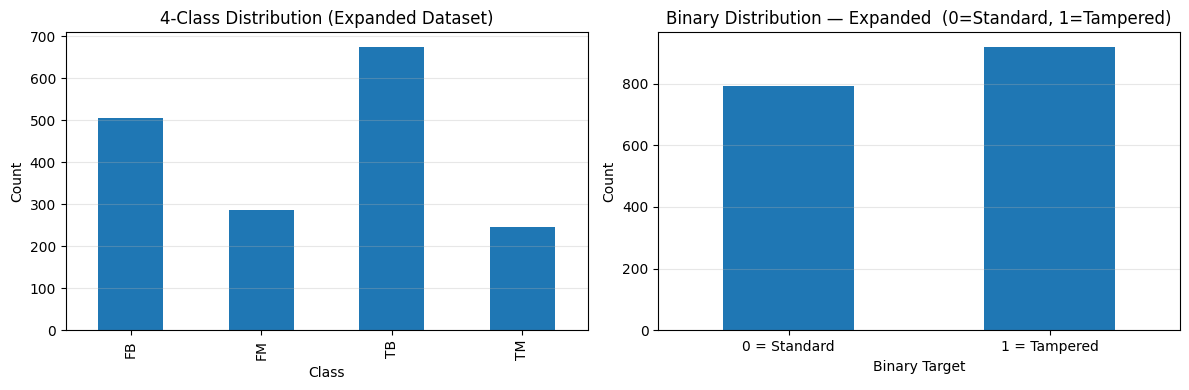

Majority-class fraction (expanded): 53.8 %


In [9]:
# Visualize 4-class and binary distributions (after expansion)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts.plot(kind="bar", ax=axes[0], title="4-Class Distribution (Expanded Dataset)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", alpha=0.3)

work_df["target"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Binary Distribution — Expanded  (0=Standard, 1=Tampered)"
)
axes[1].set_xlabel("Binary Target")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["0 = Standard", "1 = Tampered"], rotation=0)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

majority_pct = work_df["target"].value_counts(normalize=True).max() * 100
print(f"Majority-class fraction (expanded): {majority_pct:.1f} %")


## Train / Test Split, Datasets, and Balanced Sampling

We stratify the split by binary target so both sets reflect the original class ratio.

To prevent the model from ignoring the minority class during training we use two complementary techniques:

1. **`pos_weight` in `BCEWithLogitsLoss`** — the minority (tampered) class contributes `pos_weight × loss` per sample, matching the frequency imbalance.
2. **`WeightedRandomSampler`** — oversamples the minority class so each mini-batch contains a balanced mix, giving the model more gradient signal from rare examples.

In [10]:
def subject_level_split(
    df: pd.DataFrame,
    target_col: str,
    test_size: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split the dataframe keeping all rows for a UUID in the same partition.

    Strategy
    --------
    1. Compute each subject's majority binary label (most-common value of
       `target_col` for that UUID).
    2. Stratify the *subject list* by that majority label so both partitions
       reflect the overall class balance.
    3. Return all rows belonging to the selected UUIDs.

    This guarantees that no volume contributes patches to both train and test,
    preventing data leakage introduced by the slice-expansion step.
    """
    rng = np.random.default_rng(seed)

    # Per-subject majority label
    subject_labels = (
        df.groupby("uuid")[target_col]
        .agg(lambda x: x.mode()[0])
    )
    uuids  = subject_labels.index.to_numpy()
    labels = subject_labels.values

    train_uuids: List[str] = []
    test_uuids:  List[str] = []

    for cls in np.unique(labels):
        cls_uuids = uuids[labels == cls].copy()
        rng.shuffle(cls_uuids)
        n_test = max(1, int(round(len(cls_uuids) * test_size)))
        test_uuids.extend(cls_uuids[:n_test].tolist())
        train_uuids.extend(cls_uuids[n_test:].tolist())

    train_df = (
        df[df["uuid"].isin(train_uuids)]
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    test_df = (
        df[df["uuid"].isin(test_uuids)]
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )
    return train_df, test_df


train_df, test_df = subject_level_split(
    work_df, target_col="target", test_size=CFG.test_size, seed=CFG.seed
)

# Verify no subject leakage
assert len(set(train_df["uuid"]) & set(test_df["uuid"])) == 0, \
    "Subject leakage detected between train and test!"

print(f"Train rows: {len(train_df)} | {train_df['uuid'].nunique()} unique subjects")
print(f"Test  rows: {len(test_df)}  | {test_df['uuid'].nunique()} unique subjects")
print("\nTrain binary distribution (proportions):")
print(train_df["target"].value_counts(normalize=True).sort_index())
print("Test binary distribution (proportions):")
print(test_df["target"].value_counts(normalize=True).sort_index())

# Persist the split for reproducibility
CFG.export_root.mkdir(parents=True, exist_ok=True)
train_df.to_csv(CFG.train_csv, index=False)
test_df.to_csv(CFG.test_csv, index=False)

# Build CTPatchDatasets (4-class labels) then wrap with binary adapter
train_multi_ds = CTPatchDataset(CFG.export_root, CFG.train_csv, CFG.patch_size, CFG.augment_train, CFG.jitter_px)
test_multi_ds  = CTPatchDataset(CFG.export_root, CFG.test_csv,  CFG.patch_size, CFG.augment_eval, 0)

class BinaryLabelDataset(Dataset):
    """Wraps a 4-class CTPatchDataset and converts labels to binary.

    Classes 0,1 (FB, FM) → 0 (Standard)
    Classes 2,3 (TB, TM) → 1 (Tampered)
    """
    def __init__(self, base_ds: Dataset):
        self.base_ds = base_ds

    def __len__(self) -> int:
        return len(self.base_ds)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        patch, y4 = self.base_ds[idx]
        ybin = torch.tensor(1.0 if int(y4) >= 2 else 0.0, dtype=torch.float32)
        return patch, ybin

train_ds = BinaryLabelDataset(train_multi_ds)
test_ds  = BinaryLabelDataset(test_multi_ds)

# Build per-sample weights for WeightedRandomSampler
train_targets = np.array([
    int(train_df.iloc[i]["target"])
    for i in range(len(train_df))
], dtype=np.int64)

class_sample_counts = np.bincount(train_targets)              # [n_neg, n_pos]
weight_per_class    = 1.0 / class_sample_counts               # [w_neg, w_pos]
sample_weights      = weight_per_class[train_targets]         # one weight per row
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights.astype(np.float32)),
    num_samples=len(sample_weights),
    replacement=True,
)

x0, y0 = train_ds[0]
print(f"\nSample patch shape: {tuple(x0.shape)}  binary label: {int(y0)}")
print(f"class_counts in train: neg={class_sample_counts[0]}  pos={class_sample_counts[1]}")


Train rows: 1380 | 78 unique subjects
Test  rows: 331  | 20 unique subjects

Train binary distribution (proportions):
target
0    0.466667
1    0.533333
Name: proportion, dtype: float64
Test binary distribution (proportions):
target
0    0.444109
1    0.555891
Name: proportion, dtype: float64

Sample patch shape: (1, 32, 32)  binary label: 0
class_counts in train: neg=644  pos=736


In [11]:
# Train loader uses WeightedRandomSampler (shuffle=False because sampler handles it)
train_loader = DataLoader(
    train_ds,
    batch_size=CFG.batch_size,
    sampler=sampler,         # balanced oversampling of minority class
    num_workers=0,
)
# Test loader is unshuffled — we need consistent ordering for evaluation
test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("Batch x shape:", tuple(xb.shape), xb.dtype)
print("Batch y shape:", tuple(yb.shape), yb.dtype)
print(f"Approx positive fraction in one batch: {yb.mean():.2f}  (should be ~0.50 with balanced sampler)")

Batch x shape: (32, 1, 32, 32) torch.float32
Batch y shape: (32,) torch.float32
Approx positive fraction in one batch: 0.44  (should be ~0.50 with balanced sampler)


## Sanity Check: Sample Patches

Before training, visualise a random selection of 32×32 patches with their binary labels to confirm:

1. The HU-normalisation puts values in [0, 1] — the patches should look like grey-scale CT slices.
2. Labels are assigned correctly — green (Standard) and red (Tampered) titles should agree with what you'd expect from the original DICOM metadata.
3. Patches are roughly centred on the annotated coordinate and contain meaningful anatomy (the smaller 32×32 crop focuses tightly on the nodule region).

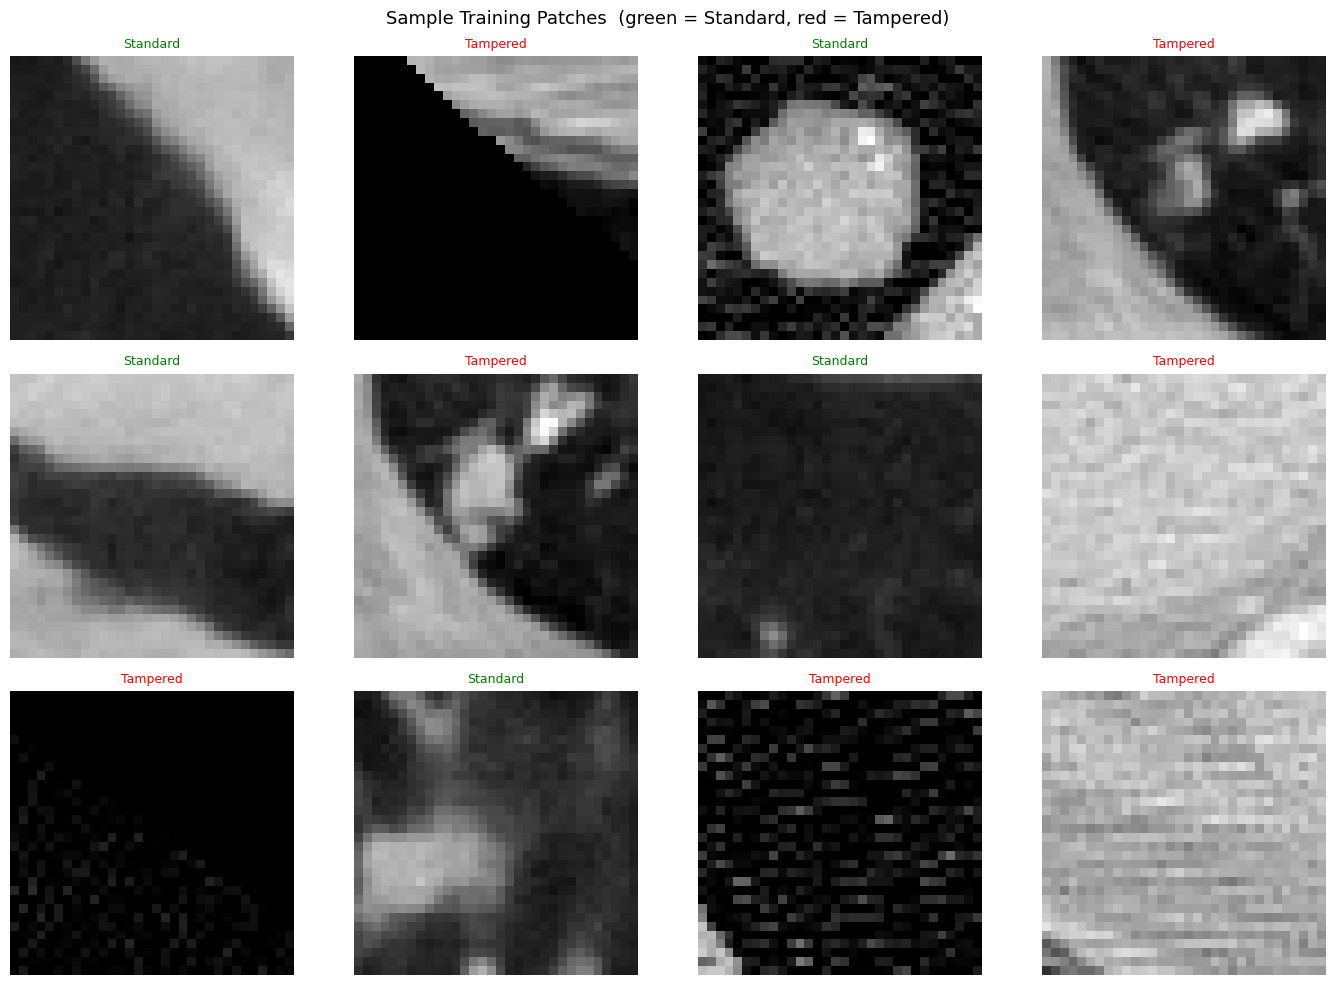

In [12]:
# ── Plot 12 random training patches ───────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()
rng_vis = np.random.default_rng(0)
sample_idxs = rng_vis.choice(len(train_ds), size=12, replace=False)

for ax, idx in zip(axes, sample_idxs):
    patch, label = train_ds[int(idx)]
    label_int = int(label.item())
    ax.imshow(patch.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(
        f"{'Tampered' if label_int == 1 else 'Standard'}",
        color="red" if label_int == 1 else "green",
        fontsize=9,
    )
    ax.axis("off")

plt.suptitle("Sample Training Patches  (green = Standard, red = Tampered)", fontsize=13)
plt.tight_layout()
plt.show()

UUID=2495  label=TM  annotated (z,x,y)=(132,476,257)
Volume shape: Z=481, H=512, W=512
Showing slices: [129, 130, 131, 132, 133, 134, 135]


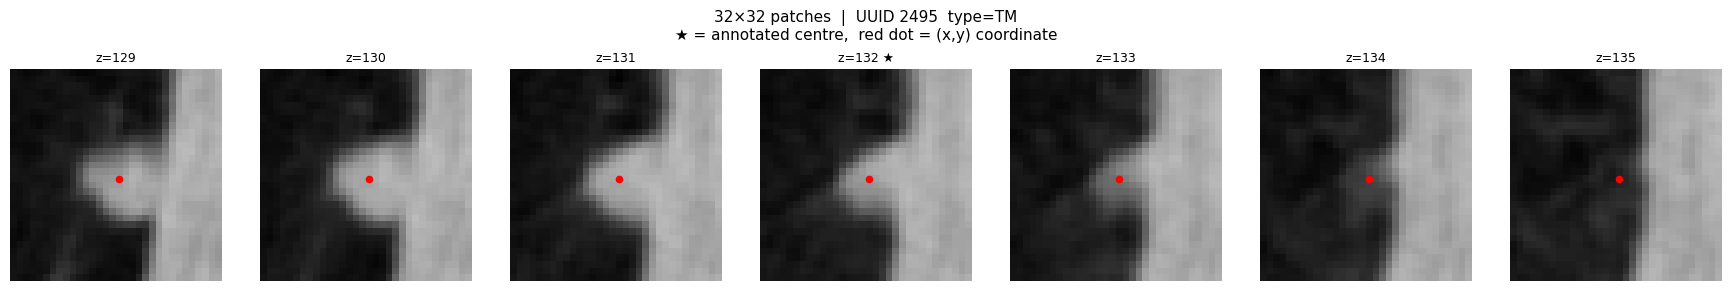


TB rows in train set: 540  across 12 subjects


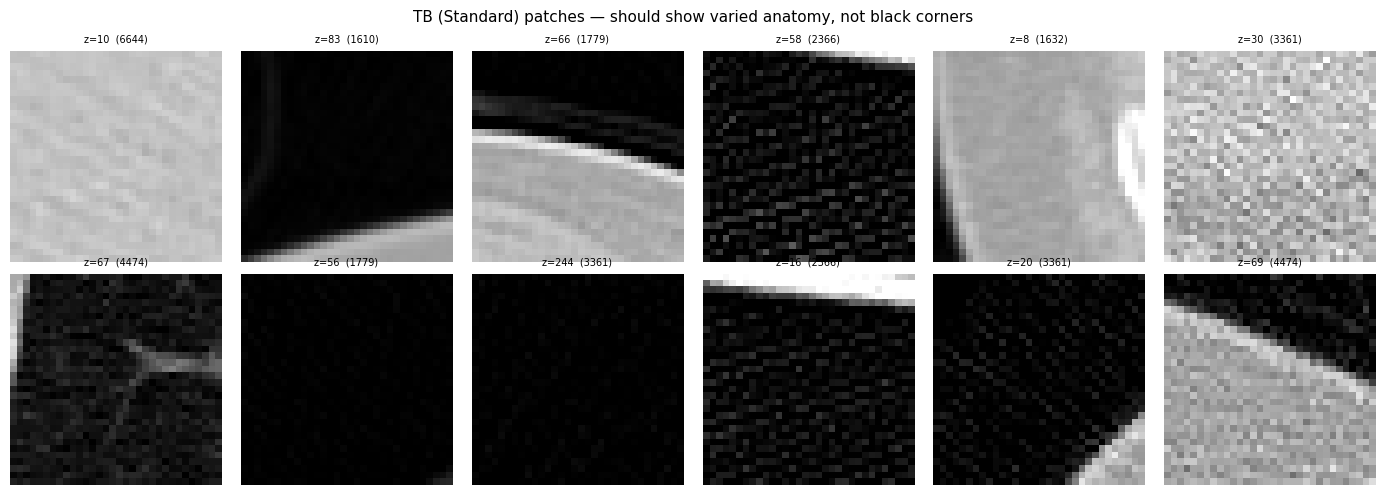

In [13]:
# ── Context sanity-check: expanded slices for a non-TB row ────────────────────
# Use expand_depth from CFG so this cell stays in sync with the expansion step.
sample_row_ctx = train_df[train_df["type"] != "TB"].sample(n=1, random_state=99).iloc[0]

uuid_ctx   = str(sample_row_ctx["uuid"])
z_center   = int(sample_row_ctx["slice"])
x_ctx      = int(sample_row_ctx["x"])
y_ctx      = int(sample_row_ctx["y"])
label_type = str(sample_row_ctx["type"])

vpath_ctx = CFG.export_root / uuid_ctx / "volume.npz"
vol_ctx = np.load(vpath_ctx, allow_pickle=False)[CFG.volume_key]

# Show at most expand_depth neighbours on each side (clamped to volume bounds)
depth_ctx = CFG.expand_depth
z_indices = [
    z for z in range(z_center - depth_ctx, z_center + depth_ctx + 1)
    if 0 <= z < vol_ctx.shape[0]
]

print(f"UUID={uuid_ctx}  label={label_type}  annotated (z,x,y)=({z_center},{x_ctx},{y_ctx})")
print(f"Volume shape: Z={vol_ctx.shape[0]}, H={vol_ctx.shape[1]}, W={vol_ctx.shape[2]}")
print(f"Showing slices: {z_indices}")

patch_sz = CFG.patch_size
hs = patch_sz // 2

def _crop_patch(slice_img: np.ndarray, cx: int, cy: int, sz: int) -> np.ndarray:
    h, w = slice_img.shape
    y0c = max(cy - hs, 0); y1c = min(cy + hs, h)
    x0c = max(cx - hs, 0); x1c = min(cx + hs, w)
    return slice_img[y0c:y1c, x0c:x1c]

fig, axes = plt.subplots(1, len(z_indices), figsize=(2.5 * len(z_indices), 2.8),
                         constrained_layout=True)
if len(z_indices) == 1:
    axes = [axes]

for ax, z in zip(axes, z_indices):
    patch = _crop_patch(vol_ctx[z], x_ctx, y_ctx, patch_sz)
    ax.imshow(patch, cmap="gray", vmin=0, vmax=1)
    ax.scatter([x_ctx - max(x_ctx - hs, 0)], [y_ctx - max(y_ctx - hs, 0)], c="red", s=20)
    ax.set_title(f"z={z}" + (" ★" if z == z_center else ""), fontsize=9)
    ax.axis("off")

plt.suptitle(
    f"{patch_sz}×{patch_sz} patches  |  UUID {uuid_ctx}  type={label_type}\n"
    "★ = annotated centre,  red dot = (x,y) coordinate",
    fontsize=11,
)
plt.show()

# ── Also verify TB volumes now produce varied patches (not black corners) ─────
tb_rows_train = train_df[train_df["type"] == "TB"]
print(f"\nTB rows in train set: {len(tb_rows_train)}  across {tb_rows_train['uuid'].nunique()} subjects")
if len(tb_rows_train) > 0:
    fig2, axes2 = plt.subplots(2, 6, figsize=(14, 5))
    axes2 = axes2.ravel()
    sample_tb = tb_rows_train.sample(n=min(12, len(tb_rows_train)), random_state=7)
    for ax, (_, r) in zip(axes2, sample_tb.iterrows()):
        vol_tb = np.load(CFG.export_root / str(r["uuid"]) / "volume.npz",
                         allow_pickle=False)[CFG.volume_key]
        patch_tb = _crop_patch(vol_tb[int(r["slice"])], int(r["x"]), int(r["y"]), patch_sz)
        ax.imshow(patch_tb, cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"z={r['slice']}  ({r['uuid']})", fontsize=7)
        ax.axis("off")
    for ax in axes2[len(sample_tb):]:
        ax.axis("off")
    plt.suptitle("TB (Standard) patches — should show varied anatomy, not black corners", fontsize=11)
    plt.tight_layout()
    plt.show()


## Enhanced Model Architecture

The original 3-layer CNN (≈20 k params, no regularisation) was too shallow to learn meaningful differences between standard and tampered scans.  The replacement `ImprovedBinaryCNN` features:

- **4 double-conv blocks** with progressively more filters: 1 → 32 → 64 → 128 → 256
- **Batch Normalisation** after every convolution for stable, faster convergence
- **Dropout (p = 0.4)** before the linear head to prevent over-fitting on the small dataset
- **AdaptiveAvgPool2d(1,1)** so the model works regardless of patch size

Total trainable parameters ≈ 1.2 M — large enough to capture texture/edge anomalies introduced by tampering, small enough to avoid severe over-fitting on ~100 subjects.

In [22]:
class ImprovedBinaryCNN(nn.Module):
    """4-block CNN with BatchNorm + Dropout for CT patch binary classification.

    Architecture:
      Block 1-4: Conv2d → BN → ReLU → MaxPool  (channels: 1→32→64→128→256)
      Head:      AdaptiveAvgPool → Flatten → Dropout(0.4) → Linear(256→1)

    The progressive doubling of channels lets early layers capture low-level
    textures and later layers capture higher-level structural anomalies.
    """

    def _block(self, in_ch: int, out_ch: int) -> nn.Sequential:
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            self._block(1,   32),   # 32→16
            self._block(32,  64),   # 16→8
            self._block(64,  128),  # 8→4
            self._block(128, 256),  # 4→2
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.head(x).squeeze(1)


model = ImprovedBinaryCNN().to(CFG.device)

# Weighted loss: upweights the minority (tampered) class
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32, device=CFG.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)

# CosineAnnealingWarmRestarts: LR oscillates between lr and eta_min with
# warm restarts every T0, 2*T0, 4*T0, … epochs, forcing the optimiser to
# escape shallow local minima and explore the full loss landscape.
# Over 100 epochs with T0=10, T_mult=2: restarts at epochs 10, 30, 70.
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=CFG.cosine_T0,
    T_mult=CFG.cosine_T_mult,
    eta_min=CFG.cosine_eta_min,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"LR schedule: CosineAnnealingWarmRestarts  T_0={CFG.cosine_T0}  T_mult={CFG.cosine_T_mult}  eta_min={CFG.cosine_eta_min}")


ImprovedBinaryCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): R

In [23]:
def evaluate(
    model: nn.Module, loader: DataLoader, criterion: nn.Module, device: str
) -> Tuple[float, float, float, float]:
    """Returns (val_loss, accuracy, macro_f1, roc_auc)."""
    model.eval()
    running_loss = 0.0
    all_probs: List[float] = []
    all_preds: List[int] = []
    all_labels: List[int] = []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_probs.extend(probs.tolist())
            all_preds.extend(preds.tolist())
            all_labels.extend(yb.cpu().numpy().tolist())

    n = len(loader.dataset)
    avg_loss = running_loss / n
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    try:
        roc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc = float("nan")
    return avg_loss, float(acc), float(f1), float(roc)


# ── Training history ─────────────────────────────────────────────────────────
history: Dict[str, List] = {
    "epoch": [],
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [], "val_auc": [],
    "lr": [],
}

# Early stopping state
best_val_f1 = -1.0
epochs_no_improve = 0
best_state_dict: Optional[Dict] = None

print(f"{'Epoch':>5} {'TrainLoss':>10} {'ValLoss':>9} {'Acc':>6} {'F1':>6} {'AUC':>6} {'LR':>9}")
print("-" * 58)

for epoch in range(CFG.epochs):
    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(CFG.device), yb.to(CFG.device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ── Validate ─────────────────────────────────────────────────────────────
    val_loss, val_acc, val_f1, val_auc = evaluate(model, test_loader, criterion, CFG.device)

    # CosineAnnealingWarmRestarts: step once per epoch
    # Passing (epoch + 1) aligns the internal cycle counter with wall-clock epochs
    scheduler.step(epoch + 1)
    current_lr = optimizer.param_groups[0]["lr"]

    # Record
    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_auc"].append(val_auc)
    history["lr"].append(current_lr)

    print(
        f"{epoch+1:5d} {train_loss:10.4f} {val_loss:9.4f} "
        f"{val_acc:6.3f} {val_f1:6.3f} {val_auc:6.3f} {current_lr:9.2e}"
    )

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_f1 > best_val_f1 + CFG.min_delta:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        import copy
        best_state_dict = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= CFG.early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1} (best val F1={best_val_f1:.4f})")
            break

# Restore best weights
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"\nRestored best model weights (val F1={best_val_f1:.4f})")

# ── Save best weights ─────────────────────────────────────────────────────────
CFG.weights_dir.mkdir(parents=True, exist_ok=True)
weights_path = CFG.weights_dir / "basic_CNN.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "val_f1": best_val_f1,
        "epoch": history["epoch"][-1],
        "config": {
            "patch_size": CFG.patch_size,
            "epochs_trained": len(history["epoch"]),
        },
    },
    weights_path,
)
print(f"\nBest model weights saved → {weights_path}")


Epoch  TrainLoss   ValLoss    Acc     F1    AUC        LR
----------------------------------------------------------
    1     0.3913    0.9060  0.722  0.716  0.850  4.88e-04
    2     0.3115    0.7905  0.707  0.693  0.855  4.52e-04
    3     0.2916    0.3698  0.831  0.831  0.935  3.97e-04
    4     0.2711    0.3347  0.840  0.840  0.927  3.28e-04
    5     0.2387    0.3122  0.882  0.881  0.933  2.51e-04
    6     0.1941    0.2515  0.876  0.872  0.960  1.73e-04
    7     0.1700    0.2020  0.927  0.926  0.969  1.04e-04
    8     0.1598    0.2101  0.900  0.898  0.969  4.87e-05
    9     0.1686    0.1550  0.946  0.945  0.987  1.32e-05
   10     0.1362    0.1546  0.940  0.939  0.985  5.00e-04
   11     0.2787    0.4301  0.825  0.821  0.880  4.97e-04
   12     0.2175    0.2575  0.870  0.867  0.956  4.88e-04
   13     0.2192    0.3074  0.885  0.883  0.945  4.73e-04
   14     0.1573    0.2432  0.909  0.909  0.970  4.52e-04
   15     0.1638    0.2455  0.882  0.882  0.975  4.27e-04
   16     0.1

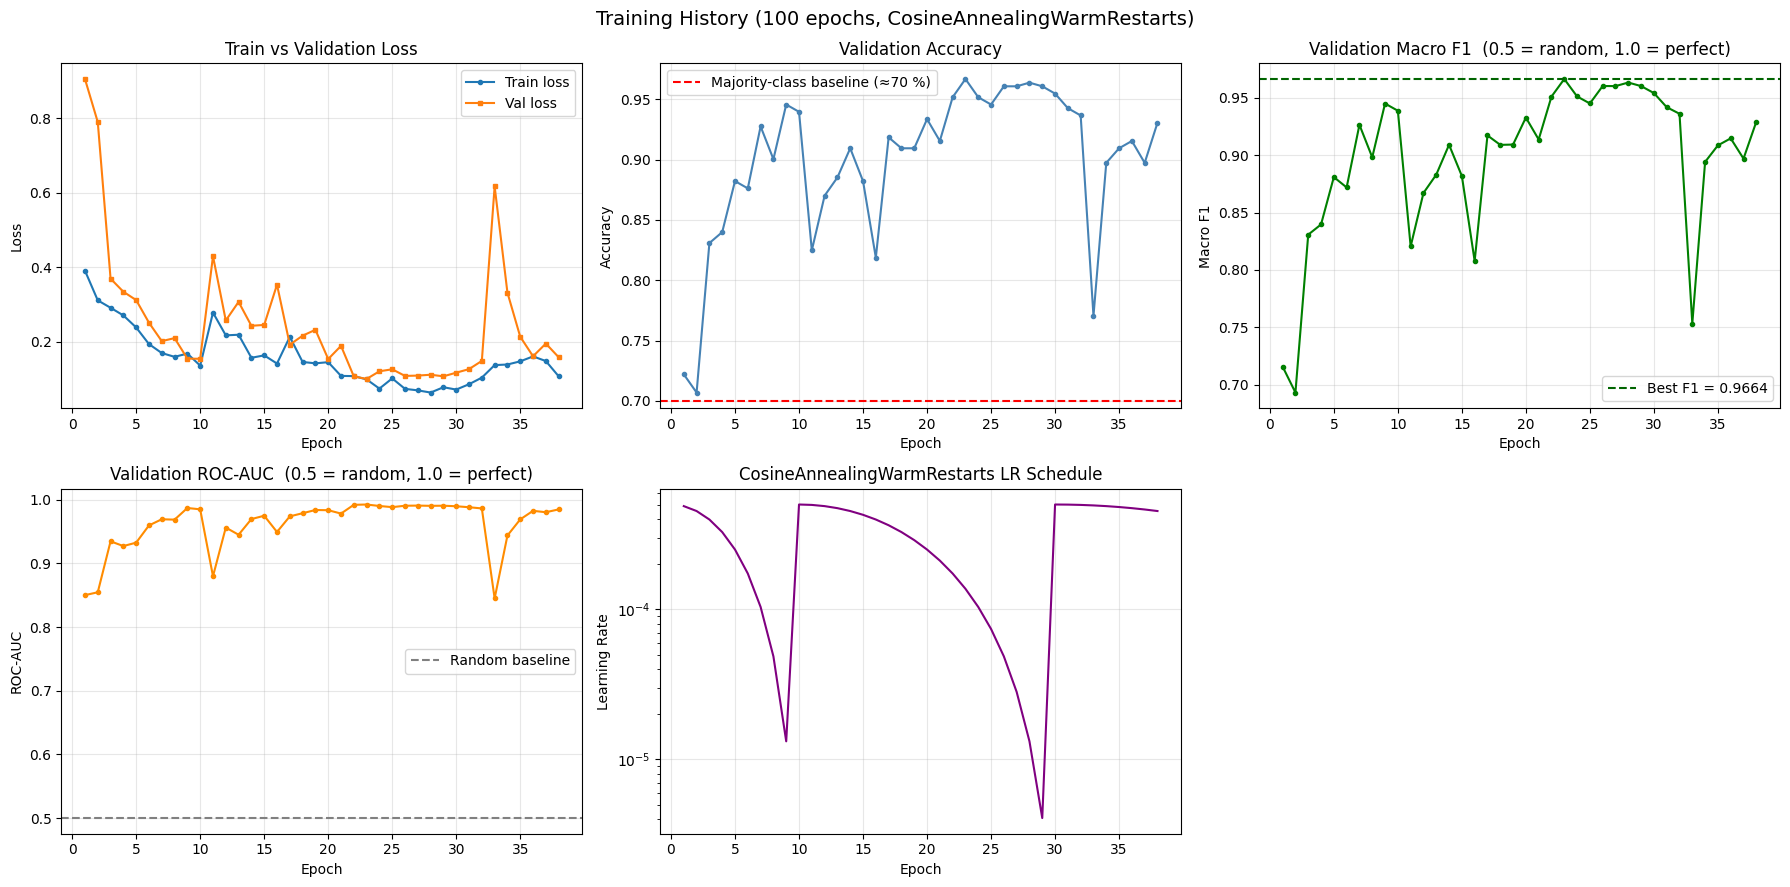

In [24]:
hist = history  # shorthand

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

# ── Loss ─────────────────────────────────────────────────────────────────────
axes[0].plot(hist["epoch"], hist["train_loss"], marker="o", markersize=3, label="Train loss")
axes[0].plot(hist["epoch"], hist["val_loss"],   marker="s", markersize=3, label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Validation Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# ── Validation Accuracy ───────────────────────────────────────────────────────
axes[1].plot(hist["epoch"], hist["val_acc"], marker="o", markersize=3, color="steelblue")
axes[1].axhline(0.70, linestyle="--", color="red", label="Majority-class baseline (≈70 %)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# ── Macro F1 ─────────────────────────────────────────────────────────────────
axes[2].plot(hist["epoch"], hist["val_f1"], marker="o", markersize=3, color="green")
axes[2].axhline(best_val_f1, linestyle="--", color="darkgreen",
                label=f"Best F1 = {best_val_f1:.4f}")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Macro F1")
axes[2].set_title("Validation Macro F1  (0.5 = random, 1.0 = perfect)")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

# ── ROC-AUC ──────────────────────────────────────────────────────────────────
axes[3].plot(hist["epoch"], hist["val_auc"], marker="o", markersize=3, color="darkorange")
axes[3].axhline(0.5, linestyle="--", color="grey", label="Random baseline")
axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("ROC-AUC")
axes[3].set_title("Validation ROC-AUC  (0.5 = random, 1.0 = perfect)")
axes[3].legend(); axes[3].grid(True, alpha=0.3)

# ── Learning Rate ─────────────────────────────────────────────────────────────
axes[4].plot(hist["epoch"], hist["lr"], color="purple", lw=1.5)
axes[4].set_xlabel("Epoch"); axes[4].set_ylabel("Learning Rate")
axes[4].set_title("CosineAnnealingWarmRestarts LR Schedule")
axes[4].set_yscale("log")
axes[4].grid(True, alpha=0.3)

# Hide the unused 6th panel
axes[5].axis("off")

plt.suptitle("Training History (100 epochs, CosineAnnealingWarmRestarts)", fontsize=14)
plt.tight_layout()
plt.show()


## Evaluation: Beyond Accuracy

Raw accuracy is misleading on imbalanced data. We use three complementary diagnostics:

| Metric | Why it matters |
|--------|---------------|
| **Confusion matrix** | Shows false negatives (tampered missed) and false positives (standard flagged) separately — clinical costs differ |
| **Precision / Recall / F1** | Unaffected by majority-class size; macro-F1 weighs both classes equally |
| **ROC-AUC** | Measures ranking quality across all decision thresholds; 0.5 = random, 1.0 = perfect |

A model that always predicts "Standard" would score F1 ≈ 0.40 (good Standard class, zero recall for Tampered) and AUC = 0.50.

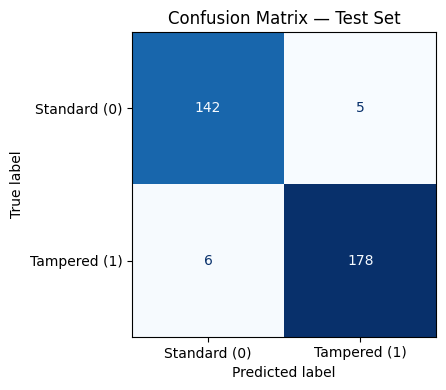


Classification Report:
              precision    recall  f1-score   support

    Standard     0.9595    0.9660    0.9627       147
    Tampered     0.9727    0.9674    0.9700       184

    accuracy                         0.9668       331
   macro avg     0.9661    0.9667    0.9664       331
weighted avg     0.9668    0.9668    0.9668       331



In [25]:
# ── Confusion matrix + classification report ──────────────────────────────────
model.eval()
all_preds_cm: List[int] = []
all_labels_cm: List[int] = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(CFG.device)
        logits = model(xb)
        preds = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
        all_preds_cm.extend(preds.tolist())
        all_labels_cm.extend(yb.numpy().astype(int).tolist())

cm = confusion_matrix(all_labels_cm, all_preds_cm)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Standard (0)", "Tampered (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(
    all_labels_cm, all_preds_cm,
    target_names=["Standard", "Tampered"],
    digits=4,
))

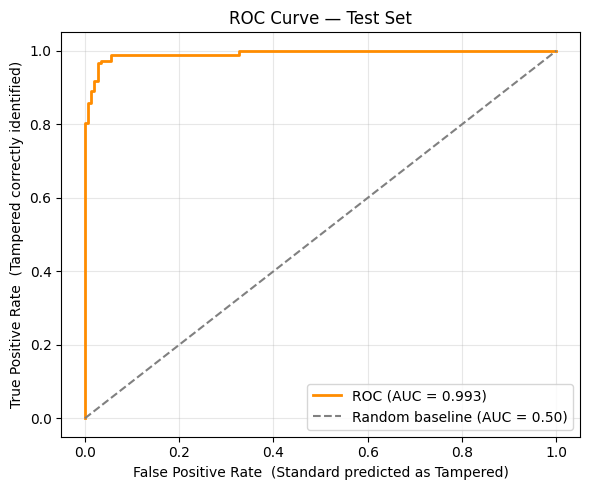

Test ROC-AUC: 0.9927


In [26]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
model.eval()
all_probs_roc: List[float] = []
all_labels_roc: List[int] = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(CFG.device)
        probs = torch.sigmoid(model(xb)).cpu().numpy()
        all_probs_roc.extend(probs.tolist())
        all_labels_roc.extend(yb.numpy().astype(int).tolist())

fpr, tpr, _ = roc_curve(all_labels_roc, all_probs_roc)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color="darkorange", label=f"ROC (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", lw=1.5, color="grey", label="Random baseline (AUC = 0.50)")
ax.set_xlabel("False Positive Rate  (Standard predicted as Tampered)")
ax.set_ylabel("True Positive Rate  (Tampered correctly identified)")
ax.set_title("ROC Curve — Test Set")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Test ROC-AUC: {roc_auc:.4f}")

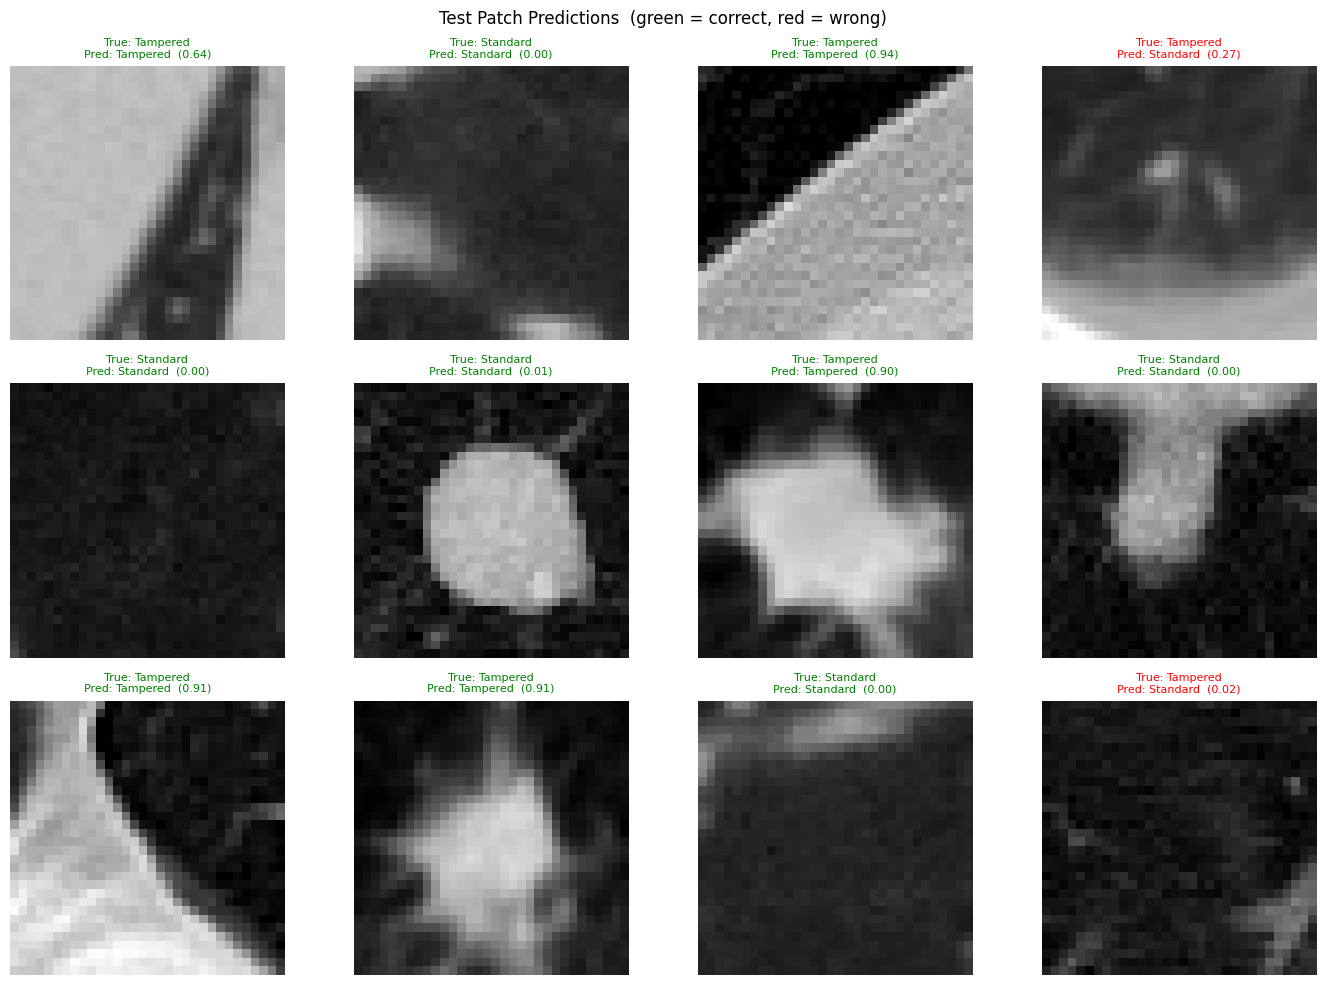

In [33]:
# ── Sample predictions on test set ────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()
rng_vis2 = np.random.default_rng()
sample_idxs2 = rng_vis2.choice(len(test_ds), size=12, replace=False)

model.eval()
for ax, idx in zip(axes, sample_idxs2):
    patch, true_label = test_ds[int(idx)]
    true_int = int(true_label.item())
    with torch.no_grad():
        prob = torch.sigmoid(model(patch.unsqueeze(0).to(CFG.device))).item()
    pred_int = int(prob >= 0.5)
    match = pred_int == true_int
    ax.imshow(patch.squeeze().numpy(), cmap="gray", vmin=0, vmax=1)
    label_str = (
        f"True: {'Tampered' if true_int else 'Standard'}\n"
        f"Pred: {'Tampered' if pred_int else 'Standard'}  ({prob:.2f})"
    )
    ax.set_title(label_str, color="green" if match else "red", fontsize=8)
    ax.axis("off")

plt.suptitle("Test Patch Predictions  (green = correct, red = wrong)", fontsize=12)
plt.tight_layout()
plt.show()

Total misclassifications on test set: 11 / 331
  False Positives (Standard predicted as Tampered): 5
  False Negatives (Tampered predicted as Standard): 6


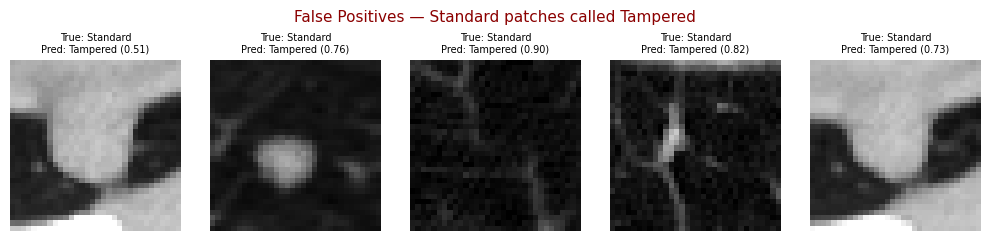

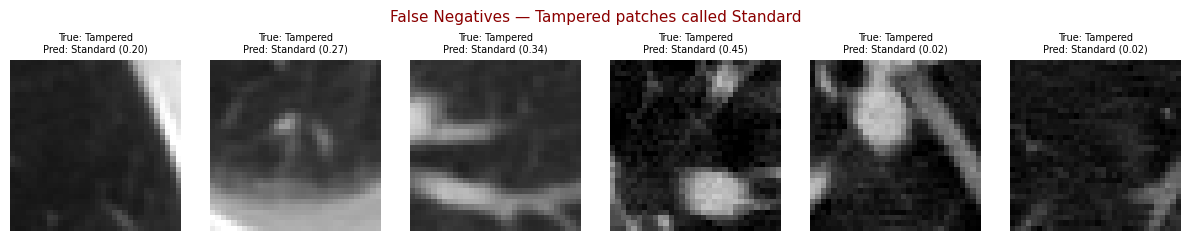

In [28]:
# ── Visualise ALL misclassified test examples ─────────────────────────────────
# Collect every misclassification from the test set with its probability score.
model.eval()
misclassified: List[dict] = []

with torch.no_grad():
    global_idx = 0
    for xb, yb in test_loader:
        xb_dev = xb.to(CFG.device)
        probs_batch = torch.sigmoid(model(xb_dev)).cpu().numpy()
        preds_batch = (probs_batch >= 0.5).astype(int)
        labels_batch = yb.numpy().astype(int)

        for i in range(len(labels_batch)):
            if preds_batch[i] != labels_batch[i]:
                misclassified.append({
                    "ds_idx": global_idx + i,
                    "patch": xb[i].squeeze().numpy(),  # already CPU
                    "true": labels_batch[i],
                    "pred": preds_batch[i],
                    "prob": float(probs_batch[i]),
                })
        global_idx += len(labels_batch)

print(f"Total misclassifications on test set: {len(misclassified)} / {len(test_ds)}")

# Separate FP and FN for a more informative layout
false_positives = [m for m in misclassified if m["true"] == 0 and m["pred"] == 1]
false_negatives = [m for m in misclassified if m["true"] == 1 and m["pred"] == 0]
print(f"  False Positives (Standard predicted as Tampered): {len(false_positives)}")
print(f"  False Negatives (Tampered predicted as Standard): {len(false_negatives)}")

def _plot_error_grid(cases: List[dict], title: str, max_show: int = 24):
    if not cases:
        print(f"No {title} errors to display.")
        return
    show = cases[:max_show]
    cols = min(8, len(show))
    rows = (len(show) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.3 * rows), constrained_layout=True)
    axes_flat = np.array(axes).ravel() if rows * cols > 1 else [axes]
    for ax, m in zip(axes_flat, show):
        ax.imshow(m["patch"], cmap="gray", vmin=0, vmax=1)
        true_str = "Tampered" if m["true"] == 1 else "Standard"
        pred_str = "Tampered" if m["pred"] == 1 else "Standard"
        ax.set_title(f"True: {true_str}\nPred: {pred_str} ({m['prob']:.2f})", fontsize=7)
        ax.axis("off")
    for ax in axes_flat[len(show):]:
        ax.axis("off")
    extra = f"  (+{len(cases) - max_show} more)" if len(cases) > max_show else ""
    plt.suptitle(f"{title}{extra}", fontsize=11, color="darkred")
    plt.show()

_plot_error_grid(false_positives, "False Positives — Standard patches called Tampered")
_plot_error_grid(false_negatives, "False Negatives — Tampered patches called Standard")


In [29]:
# ── Final evaluation on entire train and test sets ───────────────────────────
_, final_train_acc, final_train_f1, final_train_auc = evaluate(model, train_loader, criterion, CFG.device)
_, final_test_acc,  final_test_f1,  final_test_auc  = evaluate(model, test_loader,  criterion, CFG.device)

print("=" * 54)
print(f"{'Metric':<22} {'Train':>10} {'Test':>10}")
print("-" * 54)
print(f"{'Accuracy':<22} {final_train_acc:>10.4f} {final_test_acc:>10.4f}")
print(f"{'Macro F1':<22} {final_train_f1:>10.4f} {final_test_f1:>10.4f}")
print(f"{'ROC-AUC':<22} {final_train_auc:>10.4f} {final_test_auc:>10.4f}")
print("=" * 54)

majority_baseline = max(
    (work_df["target"] == 0).mean(),
    (work_df["target"] == 1).mean(),
)
print(f"\nMajority-class accuracy baseline : {majority_baseline:.4f}")
print(f"Model test accuracy               : {final_test_acc:.4f}  "
      + ("✓ beats baseline" if final_test_acc > majority_baseline else "✗ does not beat baseline"))
print(f"Model test macro F1               : {final_test_f1:.4f}  "
      + ("✓ above random (0.50)" if final_test_f1 > 0.50 else "✗ not above random"))

Metric                      Train       Test
------------------------------------------------------
Accuracy                   0.9594     0.9668
Macro F1                   0.9594     0.9664
ROC-AUC                    0.9954     0.9927

Majority-class accuracy baseline : 0.5377
Model test accuracy               : 0.9668  ✓ beats baseline
Model test macro F1               : 0.9664  ✓ above random (0.50)
